In [1]:
import os
import subprocess
from pathlib import Path
import tempfile

try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

import gdsfactory as gf
from gdsfactory import Component
from gdsfactory.components import text_freetype, rectangle
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist

# Base parameters for PMOS and NMOS
encoder_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation()+1.5,
        "routing_metal": "met2",
        "dummy_devices": False,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "with_dummy": (False, False),
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap": False
}

pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "with_dummy": (False, False),
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap": False
}

pdk = gf180
encoder_comp = Component(name="encoder")
encoder_comp.name = "encoder"
rules = encoder_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]

In [2]:
# ----------------------------------------------------------------------
# 1. Component Instantiation
# ----------------------------------------------------------------------

# --- Differential Pair (M1, M2): Long channel L=10u, W=0.28u ---
xm1 = nmos(pdk, width=0.5, length=10.0, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
xm2 = nmos(pdk, width=0.5, length=10.0, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult,**nmos_kwargs)

# --- Active Diode Loads (M3, M4): W=2u, L=0.28u ---
xm3 = pmos(pdk, width=2.0, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm4 = pmos(pdk, width=2.0, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

# --- Output PMOS Current Mirrors (M5, M6, M7, M8): W=0.93u, L=1.86u ---
xm5 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm8 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm6 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm7 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

# --- Tail Current Source & Bias Network (M9, M10, M11): W=0.28u, L=0.28u ---
xm9  = nmos(pdk, width=0.5, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
xm10 = nmos(pdk, width=0.5, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
xm11 = pmos(pdk, width=0.5, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

2026-08-27 00:01:49.072 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


In [3]:
# ----------------------------------------------------------------------
# 2. Structural Placement & Floorplanning
# -----------------------------------------------------------------------

# Set instance names
xm1.name  = "xm1"
xm2.name  = "xm2"
xm3.name  = "xm3"
xm4.name  = "xm4"
xm5.name  = "xm5"
xm6.name  = "xm6"
xm7.name  = "xm7"
xm8.name  = "xm8"
xm9.name  = "xm9"
xm10.name = "xm10"
xm11.name = "xm11"

# Create references for all devices in the top component
xm1_ref  = encoder_comp << xm1
xm2_ref  = encoder_comp << xm2
xm3_ref  = encoder_comp << xm3
xm4_ref  = encoder_comp << xm4
xm5_ref  = encoder_comp << xm5
xm6_ref  = encoder_comp << xm6
xm7_ref  = encoder_comp << xm7
xm8_ref  = encoder_comp << xm8
xm9_ref  = encoder_comp << xm9
xm10_ref = encoder_comp << xm10
xm11_ref = encoder_comp << xm11

#dynamic bbox
xm10_xy = evaluate_bbox(xm10)
xm9_xy  = evaluate_bbox(xm9)

xm1_xy  = evaluate_bbox(xm1)
xm2_xy  = evaluate_bbox(xm2)

xm8_xy  = evaluate_bbox(xm8)
xm5_xy  = evaluate_bbox(xm5)
xm3_xy  = evaluate_bbox(xm3)
xm11_xy = evaluate_bbox(xm11)
xm4_xy  = evaluate_bbox(xm4)
xm7_xy  = evaluate_bbox(xm7)
xm6_xy  = evaluate_bbox(xm6)


# Calculate Row Y-Coordinates dynamically to prevent Y-axis overlap
bottom_row_y = xm10_xy[1] / 2
middle_row_y = bottom_row_y + (xm10_xy[1] / 2) + spacing + (xm1_xy[1] / 2)
top_row_y    = middle_row_y + (xm1_xy[1] / 2) + spacing + (xm3_xy[1] / 2)


# # --- BOTTOM ROW: Bias & Tail NMOS Array (xm9, xm10) ---
# xm9_ref.move((0 + xm9_xy[0] / 2, bottom_row_y + xm9_xy[1] / 2))
# xm10_ref.move((xm9_ref.xmax + xm10_xy[0] / 2 + spacing, bottom_row_y + xm10_xy[1] / 2))

# # --- MIDDLE ROW: Differential Input NMOS Pair (xm1, xm2) ---
xm1_ref.move((0 + xm1_xy[0] / 2, middle_row_y + xm1_xy[1] / 2))
xm9_ref.move((xm1_ref.xmax + xm9_xy[0] / 2 + spacing, middle_row_y + xm9_xy[1] / 2))
xm10_ref.move((xm9_ref.xmax + xm10_xy[0] / 2 + spacing, middle_row_y + xm10_xy[1] / 2))
xm2_ref.move((xm10_ref.xmax + xm2_xy[0] / 2 + spacing, middle_row_y + xm2_xy[1] / 2))

# --- SINGLE ROW: NMOS Array (xm1, xm9, xm10, xm2) ---
# xm1_ref.move((0 + xm1_xy[0] / 2, bottom_row_y + xm1_xy[1] / 2))
# xm9_ref.move((xm1_ref.xmax + xm9_xy[0] / 2 + spacing, bottom_row_y + xm9_xy[1] / 2))
# xm10_ref.move((xm9_ref.xmax + xm10_xy[0] / 2 + spacing, bottom_row_y + xm10_xy[1] / 2))
# xm2_ref.move((xm10_ref.xmax + xm2_xy[0] / 2 + spacing, bottom_row_y + xm2_xy[1] / 2))

# --- TOP ROW: PMOS Array (Alineación por la base) ---
xm3_ref.move((0 + xm3_xy[0] / 2, top_row_y + xm3_xy[1] / 2))
xm5_ref.move((xm3_ref.xmax + xm5_xy[0] / 2 + spacing, top_row_y + xm5_xy[1] / 2))
xm8_ref.move((xm5_ref.xmax + xm8_xy[0] / 2 + spacing, top_row_y + xm8_xy[1] / 2))
xm11_ref.move((xm8_ref.xmax + xm11_xy[0] / 2 + spacing, top_row_y + xm11_xy[1] / 2))
xm6_ref.move((xm11_ref.xmax + xm6_xy[0] / 2 + spacing, top_row_y + xm6_xy[1] / 2))
xm7_ref.move((xm6_ref.xmax + xm7_xy[0] / 2 + spacing, top_row_y + xm7_xy[1] / 2))
xm4_ref.move((xm7_ref.xmax + xm4_xy[0] / 2 + spacing, top_row_y + xm4_xy[1] / 2))

ComponentReference (parent Component "xm4", ports ['multiplier_0_gate_W', 'gate_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_top_met_W', 'multiplier_0_leftsd_array_row0_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row0_col0_bottom_via_W', 'multiplier_0_leftsd_array_row0_col0_bottom_met_W', 'multiplier_0_leftsd_array_row0_col0_top_met_W', 'multiplier_0_row0_col0_gate_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_top_met_W', 'multiplier_0_row0_col0_rightsd_top_met_W', 'multiplier_0_leftsd_array_row1_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row1_col0_bottom_via_W', 'multiplier_0_leftsd_arr

In [4]:
# =========================================================================
# 3. ADD Vdd & VSS POWER RAILS, CONNECT SUPPLY NODES AND ADD PORTS
# =========================================================================
psize=(0.5,0.5)
# Calculate full horizontal span of the cell to draw supply rails
bbox = evaluate_bbox(encoder_comp)
top_y = encoder_comp.ymax + 3.0
bottom_y = encoder_comp.ymin - 3.0

#via m2m3
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.

#create via in every port

#via en iex1
iex1_via = encoder_comp << viam2m3
iex1_via.move(xm8_ref.ports["multiplier_0_drain_S"].center).movex(0.25).movey(0.25)

#via en iex2
iex2_via = encoder_comp << viam2m3
iex2_via.move(xm5_ref.ports["multiplier_0_drain_S"].center).movex(0.25).movey(0.25)

#via en iex3
iex3_via = encoder_comp << viam2m3
iex3_via.move(xm7_ref.ports["multiplier_0_drain_S"].center).movex(0.25).movey(0.25)

#via en iex4
iex4_via = encoder_comp << viam2m3
iex4_via.move(xm6_ref.ports["multiplier_0_drain_S"].center).movex(0.25).movey(0.25)

#via en vin
vin_via = encoder_comp << viam2m3
vin_via.move(xm1_ref.ports["multiplier_0_gate_W"].center).movex(0.25)

#via en vin_neg
vin_neg_via = encoder_comp << viam2m3
vin_neg_via.move(xm2_ref.ports["multiplier_0_gate_W"].center).movex(0.25)

#via en vdd
vdd_via = encoder_comp << viam2m3
vdd_via.move((encoder_comp.xmax/2, top_y+0.5))

#via en vss
vss_via = encoder_comp << viam2m3
vss_via.move((bbox[0]/2, bottom_y + 0.5))

# Draw horizontal metal2 power rails
Vdd_rail = encoder_comp << gf.components.rectangle(size=(bbox[0]+4, 1.0),layer=pdk.get_layer("metal2"))
Vdd_rail.move((-2, top_y))

Vss_rail = encoder_comp << gf.components.rectangle(size=(bbox[0]+4, 1.0), layer=pdk.get_layer("metal2"))
Vss_rail.move((-2, bottom_y))

#############################################################################
####################  ANILLO DE PDN  #########################################

## METAL5 TOP
bbox_vdd = evaluate_bbox(Vdd_rail)

avdd_M5 = encoder_comp << gf.components.rectangle(
    size=(bbox_vdd[0]+10, 6.13), 
    layer=pdk.get_layer("metal5")
)
avdd_M5.move((-7, top_y + bbox_vdd[1] + 2))

#m5_label
avdd_label = encoder_comp << gf.components.rectangle(
    size=(bbox_vdd[0]+10, 6.13), 
    layer=pdk.get_layer("metal5_label")
)
avdd_label.move((-7, top_y + bbox_vdd[1] + 2))

bbox_vss_M5 = evaluate_bbox(avdd_M5)

# Draw horizontal metal5 power rails
avss_M5 = encoder_comp << gf.components.rectangle(
    size=(bbox_vdd[0]+20, 6.13), 
    layer=pdk.get_layer("metal5")
)
avss_M5.move((-12, top_y + bbox_vdd[1] + bbox_vss_M5[1] + 4))

#m5 lABEL
avss_label = encoder_comp << gf.components.rectangle(
    size=(bbox_vdd[0]+20, 6.13), 
    layer=pdk.get_layer("metal5_label")
)
avss_label.move((-12, top_y + bbox_vdd[1] + bbox_vss_M5[1] + 4))


## METAL5 BOTTOM
bbox_vss = evaluate_bbox(Vss_rail)

avdd_M5_bot = encoder_comp << gf.components.rectangle(
    size=(bbox_vdd[0]+10, 6.13), 
    layer=pdk.get_layer("metal5")
)
bbox_vssbot = evaluate_bbox(avdd_M5_bot)
avdd_M5_bot.move((-7, bottom_y - bbox_vssbot[1] - 2))

#met5_label
avdd_label_bot = encoder_comp << gf.components.rectangle(
    size=(bbox_vdd[0]+10, 6.13), 
    layer=pdk.get_layer("metal5_label")
)
avdd_label_bot.move((-7, bottom_y - bbox_vssbot[1] - 2))


avss_M5_bot = encoder_comp << gf.components.rectangle(
    size=(bbox_vdd[0]+20, 6.13), 
    layer=pdk.get_layer("metal5")
)
avss_M5_bot.move((-12, bottom_y - 2 * bbox_vssbot[1] - 4))

#metal5_label VSS
avss_label_bot = encoder_comp << gf.components.rectangle(
    size=(bbox_vdd[0]+20, 6.13), 
    layer=pdk.get_layer("metal5_label")
)
avss_label_bot.move((-12, bottom_y - 2 * bbox_vssbot[1] - 4))

#verticales

#met4_label Vss left
avss1_label_m4 = encoder_comp << gf.components.rectangle(
    size=(5,50.225), #56.81
    layer=pdk.get_layer("metal4_label")
)
avss1_label_m4.move((-13,-7.28)) #38

#met4_label VDD left
avdd1_label_m4 = encoder_comp << gf.components.rectangle(
    size=(5,31.995), #56.81
    layer=pdk.get_layer("metal4_label")
)
avdd1_label_m4.move((-6,1.815)) #38

#met4_label VDD right
avdd2_label_m4 = encoder_comp << gf.components.rectangle(
    size=(5,31.995), #56.81
    layer=pdk.get_layer("metal4_label")
)
avdd2_label_m4.move((48.5, 1.815)) #38

#met4_label Vss right
avss2_label_m4 = encoder_comp << gf.components.rectangle(
    size=(5,50.225), #56.81
    layer=pdk.get_layer("metal4_label")
)
avss2_label_m4.move((55.5, -7.28)) #38


####################################### VIAS ##################################


#adding a VIA M2M5 to the avdd avss pin, moving to the center of the rail
viam2m5 = via_stack(pdk, "met2", "met5", centered=True) #met2 is the bottom layer. met5 is the top layer.
via_avdd_M5 = encoder_comp << viam2m5
via_avdd_M5.move((-3.5, top_y + bbox_vss_M5[1] - 0.5))
via_avdd_M5B = encoder_comp << viam2m5
via_avdd_M5B.move((-3.5, bottom_y - bbox_vss_M5[1] + 0.5))

encoder_comp  << straight_route(pdk, via_avdd_M5.ports["bottom_met_S"], via_avdd_M5B.ports["bottom_met_N"],glayer1="met4",glayer2="met4",width="5")
#encoder_comp  << straight_route(pdk, via_avdd_M5.ports["bottom_met_S"], via_avdd_M5B.ports["bottom_met_N"],glayer1="met4_label",glayer2="met4_label",width="5")


#adding a VIA M2M5 to the avdd avss pin, moving to the center of the rail
viam2m5 = via_stack(pdk, "met2", "met5", centered=True) #met2 is the bottom layer. met5 is the top layer.
via_avss_M5 = encoder_comp << viam2m5
via_avss_M5.move((-10.5, top_y + 2* bbox_vss_M5[1] + 2.5))
via_avss_M5B = encoder_comp << viam2m5
via_avss_M5B.move((-10.5, bottom_y - 2*bbox_vss_M5[1] - 2.5))

encoder_comp  << straight_route(pdk, via_avss_M5.ports["bottom_met_S"], via_avss_M5B.ports["bottom_met_N"],glayer1="met4",glayer2="met4",width="5")

#adding a VIA M2M5 to the avdd avss pin, moving to the center of the rail
viam2m5 = via_stack(pdk, "met2", "met5", centered=True) #met2 is the bottom layer. met5 is the top layer.
via_avddL_M5 = encoder_comp << viam2m5
via_avddL_M5.move((51, top_y + bbox_vss_M5[1] - 0.5))
via_avddL_M5B = encoder_comp << viam2m5
via_avddL_M5B.move((51, bottom_y - bbox_vss_M5[1] + 0.5))

encoder_comp  << straight_route(pdk, via_avddL_M5.ports["bottom_met_S"], via_avddL_M5B.ports["bottom_met_N"],glayer1="met4",glayer2="met4",width="5")

#adding a VIA M2M5 to the avdd avss pin, moving to the center of the rail
viam2m5 = via_stack(pdk, "met2", "met5", centered=True) #met2 is the bottom layer. met5 is the top layer.
via_avssL_M5 = encoder_comp << viam2m5
via_avssL_M5.move((58, top_y + 2* bbox_vss_M5[1] + 2.5))
via_avssL_M5B = encoder_comp << viam2m5
via_avssL_M5B.move((58, bottom_y - 2*bbox_vss_M5[1] - 2.5))

encoder_comp  << straight_route(pdk, via_avssL_M5.ports["bottom_met_S"], via_avssL_M5B.ports["bottom_met_N"],glayer1="met4",glayer2="met4",width="5")

#################################################################################

#connecting ports to ring
encoder_comp  << L_route(pdk, vdd_via.ports["bottom_met_N"], via_avddL_M5.ports["bottom_met_W"])
encoder_comp  << L_route(pdk, vss_via.ports["bottom_met_S"], via_avssL_M5B.ports["bottom_met_W"])

##################################################################################


################# ADD PORTS ##################################
# Add global ports for the supply rails
encoder_comp.add_port("Vdd", center=(bbox[0]/2, top_y + 0.5), width=1.0, orientation=180, layer=pdk.get_layer("metal5"), port_type="power")
encoder_comp.add_port("Vss", center=(bbox[0]/2, bottom_y + 0.5), width=1.0, orientation=180, layer=pdk.get_layer("metal5"), port_type="gnd")
# add label to those global ports 
# encoder_comp.add_label(text="Vdd", position=(bbox[0]/2, top_y + 0.5), layer=pdk.get_glayer("met3_label") , magnification=1)
# encoder_comp.add_label(text="Vss", position=(bbox[0]/2, bottom_y + 0.5), layer=pdk.get_glayer("met3_label") , magnification=1)

encoder_comp.add_label(
    text="Vss",                         # Etiqueta para el rail inferior
    position=(58, top_y + 2* bbox_vss_M5[1] + 2.5),
    layer=pdk.get_glayer("met5_label"),
    magnification=1.5
)

# add label to those global ports 
encoder_comp.add_label(
    text="Vdd",                         # Etiqueta para el rail superior
    position=(-3.5, top_y + bbox_vss_M5[1] - 0.5),
    layer=pdk.get_glayer("met5_label"), # Capa de etiquetas para metal2
    magnification=1.5
)

# Vin
vin_port = encoder_comp << gf.components.rectangle(size=psize, layer=pdk.get_layer("metal3"))
vin_port.move(xm1_ref.ports["multiplier_0_gate_W"].center).movey(-0.25)

encoder_comp.add_port(
    "Vin", 
    center=xm1_ref.ports["multiplier_0_gate_W"].center, 
    width=1.0, 
    orientation=180, 
    layer=pdk.get_layer("metal3"), 
    port_type="electrical"
)

encoder_comp.add_label(
    text="Vin", 
    position=xm1_ref.ports["multiplier_0_gate_W"].center, 
    layer=pdk.get_glayer("met3_label"), 
    magnification=1
)

# Vin_neg
vinneg_ref = encoder_comp << gf.components.rectangle(size=psize, layer=pdk.get_layer("metal2"))
vinneg_ref.move(xm2_ref.ports["multiplier_0_gate_W"].center).movey(-0.25)

encoder_comp.add_port(
    "Vin_neg", 
    center=xm2_ref.ports["multiplier_0_gate_W"].center, 
    width=1.0, 
    orientation=180,
    layer=pdk.get_layer("metal3"), 
    port_type="electrical"
)

encoder_comp.add_label(
    text="Vin_neg", 
    position=xm2_ref.ports["multiplier_0_gate_W"].center, 
    layer=pdk.get_glayer("met3_label"), 
    magnification=1
)

# Iex_1_i
iex1_ref = encoder_comp << gf.components.rectangle(size=psize, layer=pdk.get_layer("metal2"))
iex1_ref.move(xm8_ref.ports["multiplier_0_drain_S"].center)

encoder_comp.add_port(
    "Iex_1_i", 
    center=xm8_ref.ports["multiplier_0_drain_S"].center, 
    width=1.0, 
    orientation=270, 
    layer=pdk.get_layer("metal3"), 
    port_type="electrical"
)

encoder_comp.add_label(
    text="Iex_1_i", 
    position=xm8_ref.ports["multiplier_0_drain_S"].center, 
    layer=pdk.get_glayer("met3_label"), 
    magnification=1
)

# Iex_2_i
iex2_ref = encoder_comp << gf.components.rectangle(size=psize, layer=pdk.get_layer("metal2"))
iex2_ref.move(xm5_ref.ports["multiplier_0_drain_S"].center)

encoder_comp.add_port(
    "Iex_2_i", 
    center=xm5_ref.ports["multiplier_0_drain_S"].center, 
    width=1.0, 
    orientation=270, 
    layer=pdk.get_layer("metal3"), 
    port_type="electrical"
)

encoder_comp.add_label(
    text="Iex_2_i", 
    position=xm5_ref.ports["multiplier_0_drain_S"].center, 
    layer=pdk.get_glayer("met3_label"), 
    magnification=1
)

# Iex_3_i
iex3_ref = encoder_comp << gf.components.rectangle(size=psize, layer=pdk.get_layer("metal2"))
iex3_ref.move(xm7_ref.ports["multiplier_0_drain_S"].center)

encoder_comp.add_port(
    "Iex_3_i", 
    center=xm7_ref.ports["multiplier_0_drain_S"].center, 
    width=1.0, 
    orientation=270, 
    layer=pdk.get_layer("metal3"), 
    port_type="electrical"
)

encoder_comp.add_label(
    text="Iex_3_i", 
    position=xm7_ref.ports["multiplier_0_drain_S"].center, 
    layer=pdk.get_glayer("met3_label"), 
    magnification=1
)

# Iex_4_i
iex4_ref = encoder_comp << gf.components.rectangle(size=psize, layer=pdk.get_layer("metal2"))
iex4_ref.move(xm6_ref.ports["multiplier_0_drain_S"].center)

encoder_comp.add_port(
    "Iex_4_i", 
    center=xm6_ref.ports["multiplier_0_drain_S"].center, 
    width=1.0, 
    orientation=270, 
    layer=pdk.get_layer("metal3"), 
    port_type="electrical"
)

encoder_comp.add_label(
    text="Iex_4_i", 
    position=xm6_ref.ports["multiplier_0_drain_S"].center, 
    layer=pdk.get_glayer("met3_label"), 
    magnification=1
)

Label(text='Iex_4_i', origin=(30.38, 22.775), layer=(42, 10))

2026-08-27 00:01:58.487 | WARNING  | gdsfactory.klive:show:48 - Could not connect to klive server. Is klayout open and klive plugin installed?


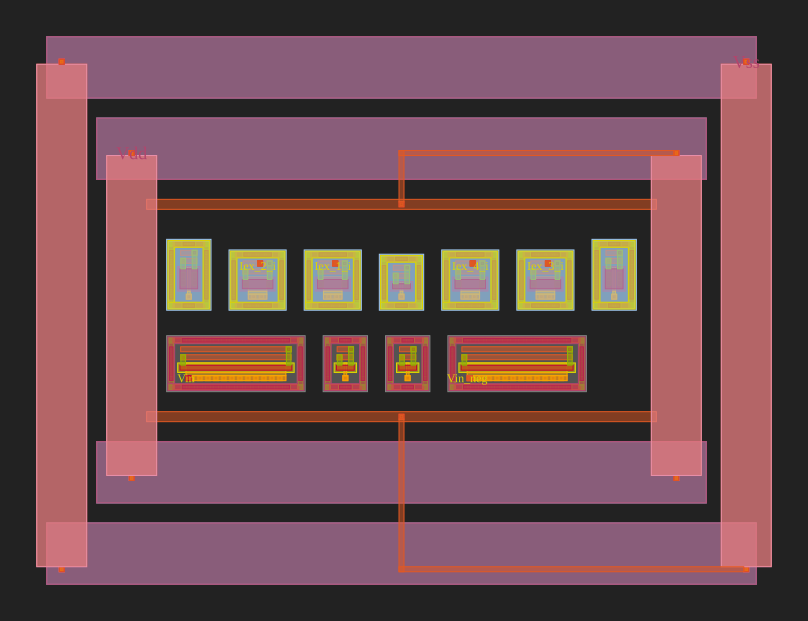

In [5]:
encoder_comp.show()
display_component(encoder_comp, scale=1, path=".")

In [6]:
# # Helper to place a metal-to-metal via stack on a port
# def place_via_on_port(comp, port_name, via_type="via1"):
#     v = comp << via_stack(pdk, via_type)
#     v.move(comp.ports[port_name].center)
#     return v

In [7]:
# ----------------------------------------------------------------------
# 4. Interconnect Routing
# ----------------------------------------------------------------------

# Connect PMOS sources to avdd rail
encoder_comp << L_route(pdk, xm8_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])
encoder_comp << L_route(pdk, xm5_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])
encoder_comp << L_route(pdk, xm3_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])
encoder_comp << L_route(pdk, xm4_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])
encoder_comp << L_route(pdk, xm7_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])
encoder_comp << L_route(pdk, xm6_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])
encoder_comp << L_route(pdk, xm11_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])


# Connect NMOS BULKS TO AVSS
encoder_comp << L_route(pdk, xm9_ref.ports["tie_W_top_met_S"], vss_via.ports["bottom_met_W"])
encoder_comp << L_route(pdk, xm10_ref.ports["tie_W_top_met_S"], vss_via.ports["bottom_met_W"])
encoder_comp << L_route(pdk, xm1_ref.ports["tie_W_top_met_S"], vss_via.ports["bottom_met_W"])
encoder_comp << L_route(pdk, xm2_ref.ports["tie_W_top_met_S"], vss_via.ports["bottom_met_W"])

# Connecting the corresponding PMOS sources to avdd
encoder_comp << L_route(pdk,  xm8_ref.ports["multiplier_0_source_E"], xm8_ref.ports["tie_E_top_met_N"])  # SOURCE XM8
encoder_comp << L_route(pdk,  xm5_ref.ports["multiplier_0_source_E"], xm5_ref.ports["tie_E_top_met_N"])   # SOURCE XM5
encoder_comp << L_route(pdk,  xm3_ref.ports["multiplier_0_source_E"], xm3_ref.ports["tie_E_top_met_N"]) # SOURCE XM3
encoder_comp << L_route(pdk,  xm4_ref.ports["multiplier_0_source_E"], xm4_ref.ports["tie_E_top_met_N"]) # SOURCE XM4
encoder_comp << L_route(pdk,  xm7_ref.ports["multiplier_0_source_E"], xm7_ref.ports["tie_E_top_met_N"])   # SOURCE XM7
encoder_comp << L_route(pdk,  xm6_ref.ports["multiplier_0_source_E"], xm6_ref.ports["tie_E_top_met_N"]) # SOURCE XM6
encoder_comp << L_route(pdk,  xm11_ref.ports["multiplier_0_source_E"], xm11_ref.ports["tie_E_top_met_N"]) # SOURCE XM11

# Connecting the corresponding NMOS SOURCES TO AVSS
encoder_comp << L_route(pdk,  xm9_ref.ports["multiplier_0_source_E"], xm9_ref.ports["tie_E_top_met_N"]) #xm9
encoder_comp << L_route(pdk,  xm10_ref.ports["multiplier_0_source_E"], xm10_ref.ports["tie_E_top_met_N"]) #xm10

# --- B. Node 'x' Connections (M1 Drain, M3 Gate/Drain, M5 Gate, M8 Gate) ---
# Route M1 Drain to M3 Drain
encoder_comp << c_route(pdk, xm1_ref.ports["multiplier_0_drain_W"], xm3_ref.ports["multiplier_0_drain_W"],extension = 2)
encoder_comp << c_route(pdk, xm3_ref.ports["multiplier_0_gate_E"], xm3_ref.ports["multiplier_0_drain_E"])
encoder_comp << straight_route(pdk, xm5_ref.ports["multiplier_0_gate_E"], xm8_ref.ports["multiplier_0_gate_W"])
encoder_comp << straight_route(pdk, xm3_ref.ports["multiplier_0_gate_E"], xm5_ref.ports["multiplier_0_gate_W"])


# # --- C. Node 'y' Connections (M2 Drain, M4 Gate/Drain, M6 Gate, M7 Gate) ---
encoder_comp << c_route(pdk, xm2_ref.ports["multiplier_0_drain_E"], xm4_ref.ports["multiplier_0_drain_E"])
encoder_comp << straight_route(pdk, xm6_ref.ports["multiplier_0_gate_W"], xm7_ref.ports["multiplier_0_gate_E"])
encoder_comp << c_route(pdk, xm4_ref.ports["multiplier_0_gate_W"], xm4_ref.ports["multiplier_0_drain_W"],extension=1.5)
encoder_comp << straight_route(pdk, xm7_ref.ports["multiplier_0_gate_E"], xm4_ref.ports["multiplier_0_gate_W"])

# # --- D. Bias Network (net1) Routing ---
encoder_comp << c_route(pdk, xm10_ref.ports["multiplier_0_gate_W"], xm10_ref.ports["multiplier_0_drain_W"], extension=1.5)
encoder_comp << c_route(pdk, xm11_ref.ports["multiplier_0_gate_W"], xm11_ref.ports["multiplier_0_drain_W"], extension=1.5)
encoder_comp << c_route(pdk, xm11_ref.ports["multiplier_0_drain_E"], xm10_ref.ports["multiplier_0_drain_E"], extension=1.5)
encoder_comp << straight_route(pdk, xm9_ref.ports["multiplier_0_gate_E"], xm10_ref.ports["multiplier_0_gate_W"])

#create via xm1xm9
xm1_xm9_via = encoder_comp << viam2m3
#via XM1 und XM9
xm1_xm9_via.move(xm1_ref.ports["multiplier_0_source_E"].center).movex(2)
encoder_comp << straight_route(pdk, xm1_ref.ports["multiplier_0_source_E"], xm1_xm9_via.ports["bottom_met_W"])
encoder_comp << L_route(pdk, xm1_xm9_via.ports["top_met_N"], xm9_ref.ports["multiplier_0_drain_W"])

#create via xm2xm9 
xm2_xm9_via = encoder_comp << viam2m3
#via XM2 und XM9
xm2_xm9_via.move(xm2_ref.ports["multiplier_0_source_E"].center).movex(2)
encoder_comp << straight_route(pdk, xm2_ref.ports["multiplier_0_source_E"], xm2_xm9_via.ports["bottom_met_W"])
encoder_comp << c_route(pdk, xm1_xm9_via.ports["top_met_N"], xm2_xm9_via.ports["top_met_N"], extension=2.5, cglayer="met2")


ComponentReference (parent Component "c_route_10e5e714", ports ['con_E', 'con_W'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

2026-08-27 00:02:01.174 | WARNING  | gdsfactory.klive:show:48 - Could not connect to klive server. Is klayout open and klive plugin installed?


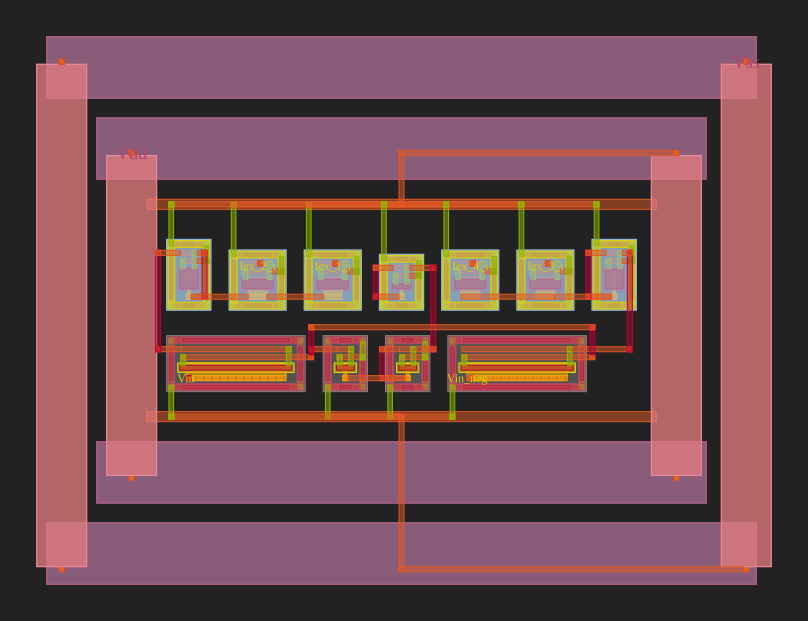

In [8]:
encoder_comp.show()
display_component(encoder_comp, scale=1, path=".")

In [9]:
bbox1 = evaluate_bbox(encoder_comp
                     )
boundary = encoder_comp << gf.components.rectangle(
    size=(bbox1[0], bbox1[1]), 
    layer=(0,0)
)
boundary.move((encoder_comp.xmin, encoder_comp.ymin))

ComponentReference (parent Component "rectangle_642ca276", ports ['e1', 'e2', 'e3', 'e4'], origin (-13.0, -9.06), rotation 0.0, x_reflection False)

2026-08-27 00:02:01.414 | WARNING  | gdsfactory.klive:show:48 - Could not connect to klive server. Is klayout open and klive plugin installed?


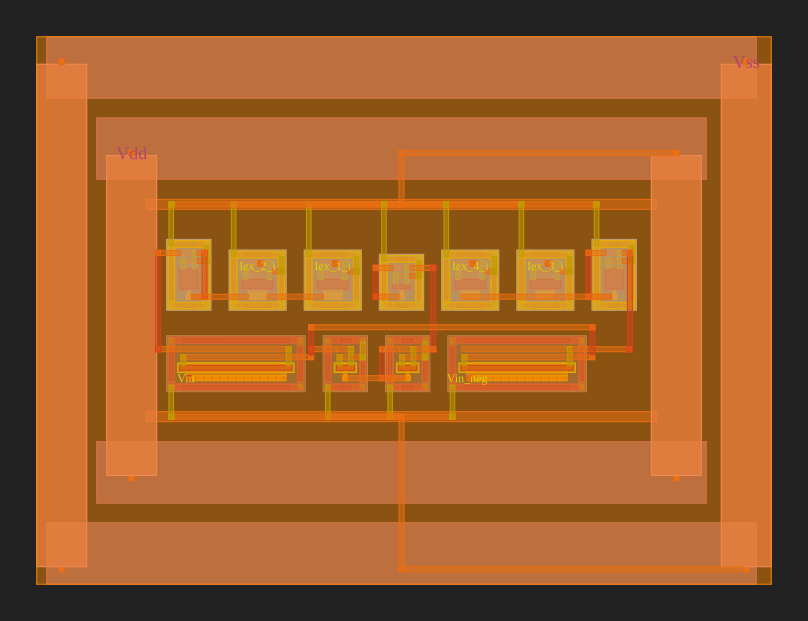

In [10]:
encoder_comp.show()
display_component(encoder_comp, scale=1, path=".")

In [11]:
help(Component.add_port)

Help on function add_port in module gdsfactory.component:

add_port(self, name: 'str | object | None' = None, center: 'tuple[float, float] | None' = None, width: 'float | None' = None, orientation: 'float | None' = None, port: 'Port | None' = None, layer: 'LayerSpec | None' = None, port_type: 'str | None' = None, cross_section: 'CrossSectionSpec | None' = None, shear_angle: 'float | None' = None) -> 'Port'
    Add port to component.
    
    You can copy an existing port like add_port(port = existing_port) or
    create a new port add_port(myname, mycenter, mywidth, myorientation).
    You can also copy an existing port
    with a new name add_port(port = existing_port, name = new_name)
    
    Args:
        name: port name.
        center: x, y.
        width: in um.
        orientation: in deg.
        port: optional port.
        layer: port layer.
        port_type: optical, electrical, vertical_dc, vertical_te, vertical_tm. Defaults to optical.
        cross_section: port cross_s

In [12]:
encoder_comp.pprint_ports()

┏━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ name    ┃ width ┃ center          ┃ orientation ┃ layer   ┃ port_type  ┃
┡━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ Vdd     │ 1.0   │ [23.5, 28.935]  │ 180         │ [81, 0] │ power      │
│ Vss     │ 1.0   │ [23.5, 7.7]     │ 180         │ [81, 0] │ gnd        │
│ Vin     │ 1.0   │ [1.93, 11.555]  │ 180         │ [42, 0] │ electrical │
│ Vin_neg │ 1.0   │ [30.07, 11.555] │ 180         │ [42, 0] │ electrical │
│ Iex_1_i │ 1.0   │ [16.62, 22.775] │ 270         │ [42, 0] │ electrical │
│ Iex_2_i │ 1.0   │ [9.1, 22.775]   │ 270         │ [42, 0] │ electrical │
│ Iex_3_i │ 1.0   │ [37.9, 22.775]  │ 270         │ [42, 0] │ electrical │
│ Iex_4_i │ 1.0   │ [30.38, 22.775] │ 270         │ [42, 0] │ electrical │
└─────────┴───────┴─────────────────┴─────────────┴─────────┴────────────┘

In [13]:
drc_result = gf180.drc_magic(encoder_comp, encoder_comp.name)

2026-08-27 00:02:01.601 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpf3i8okbr/encoder.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:13:57 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpf3i8okbr/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0

In [14]:
#At first, we need to properly set PDKPATH and PDK_ROOT 

print("Making sure your environment varriables are still correctly set")
print(" I am using PDK in: ",os.environ['PDK_ROOT'],"\n PDK name: ",os.environ['PDK'],"\n The PDK files are at: ",os.environ['PDKPATH'])

Making sure your environment varriables are still correctly set
 I am using PDK in:  /foss/pdks 
 PDK name:  gf180mcuD 
 The PDK files are at:  /foss/pdks/gf180mcuD


In [15]:
magicrc_file = Path(os.environ['PDKPATH']) / "libs.tech" / "magic" / f"{os.environ['PDK']}.magicrc"
design_name=encoder_comp.name

# Ruta donde guardas tus archivos
path_to_dir = "/foss/designs/libs/snn_analog/encoder/"

# path_to_dir = "/foss/designs/CapiMagics/layout/encoder/"

pex_path = path_to_dir + f"{design_name}.spice"
gds_path = path_to_dir + f"{design_name}.gds"

encoder_comp.write_gds(str(gds_path))
    
magic_script_content = f"""
drc off            
gds flatglob *\\$\\$*
gds read {gds_path}

flatten {design_name}
load {design_name}
select top cell
extract do local
extract all
ext2sim labels on
ext2sim
extresist tolerance 10
extresist
ext2spice lvs
ext2spice cthresh 0
ext2spice extresist on
ext2spice -o {str(pex_path)}
exit
"""

with tempfile.NamedTemporaryFile(mode='w', delete=False) as magic_script_file:
    magic_script_file.write(magic_script_content)
    magic_script_path = magic_script_file.name
    
magic_cmd = f"bash -c 'magic -rcfile {magicrc_file} -noconsole -dnull < {magic_script_path}'",
magic_subproc = subprocess.run(
    magic_cmd, 
    shell=True,
    check=True,
    capture_output=True
)
magic_subproc_code = magic_subproc.returncode
magic_subproc_out = magic_subproc.stdout.decode('utf-8')
print(magic_subproc_out)

2026-08-27 00:02:02.029 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/encoder/encoder.gds'



Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:13:57 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using GDS-II Release 6.0
Library name: library
Reading "encoder".
Reading "via_stack_a2e89513"

In [16]:
import glob
extensions = [
            "els"
            "*.gds",
            "*.ext",
            "*.res.ext",
            "*.lvs.rpt",
            "*_lvs.rpt",
            "*.nodes",
            "*.sim",
            "*.pex.spice",
            "*_pex.spice"
            ]
files_to_delete = []
for ext in extensions:
    files_to_delete.extend(glob.glob(ext))
    
# Delete the files
for file_path in files_to_delete:
    try:
        os.remove(file_path)
        print(f"Deleted: {file_path}")
    except OSError as e:
        print(f"Error deleting {file_path}: {e}")

Deleted: compass_b8003eb4$1.ext
Deleted: L_route_c53d2760.ext
Deleted: via_stack_7fdd5994$3.ext
Deleted: L_route_f4922a2b.ext
Deleted: rectangle_b8003eb4$1.ext
Deleted: rectangle_f4c83619$1.ext
Deleted: L_route_0cc5242c.ext
Deleted: L_route_b52fad3e.ext
Deleted: L_route_d349af39.ext
Deleted: xm7.ext
Deleted: via_stack_7fdd5994.ext
Deleted: L_route_0abe9712.ext
Deleted: L_route_3a0d211e.ext
Deleted: compass_4524bda4$1.ext
Deleted: compass_b8003eb4.ext
Deleted: L_route_17055af2.ext
Deleted: L_route_8d4db189.ext
Deleted: compass_f4c83619$1.ext
Deleted: rectangle_2d3cd8bd$4.ext
Deleted: rectangle_2d3cd8bd$1.ext
Deleted: xm10.ext
Deleted: rectangle_f8e4331e.ext
Deleted: c_route_10e5e714.ext
Deleted: L_route_7b4c00a0.ext
Deleted: compass_16a3fa94.ext
Deleted: via_stack_7fdd5994$2.ext
Deleted: xm9.ext
Deleted: rectangle_f8e4331e$1.ext
Deleted: L_route_3807f611.ext
Deleted: rectangle_2d1cdd23.ext
Deleted: compass_4524bda4.ext
Deleted: c_route_ea16bf50.ext
Deleted: compass_7f8659cc.ext
Deleted:

In [17]:
import os
from pathlib import Path

# Ruta donde guardas tus archivos de la neurona
path_to_dir = "/foss/designs/libs/snn_analog/encoder/"

# Ejecutar LVS con Netgen usando el PDK gf180
gf180.lvs_netgen(
    layout=encoder_comp,   # tu layout exportado
    design_name=encoder_comp.name,   # nombre del diseño
    pdk_root=Path(os.environ['PDKPATH']),   # raíz del PDK
    lvs_setup_tcl_file=Path(os.environ['PDKPATH']) / "libs.tech" / "netgen" / f"{os.environ['PDK']}_setup.tcl",
    
    # Netlist de referencia (esquemático ideal)
    lvs_schematic_ref_file=Path(path_to_dir + "encoder.spice"),
    
    # Netlist extraído del layout (PEX/LVS)
    netlist=Path(path_to_dir + "encoder_lvs.spice"),
    
    # Carpeta donde se guarda el reporte .lvs.rpt
    output_file_path=Path(path_to_dir)
)


# gf180.lvs_netgen(
#     layout=encoder_comp,
#     design_name = encoder_comp.name,
#     pdk_root = Path(os.environ['PDKPATH']),
#     lvs_setup_tcl_file = Path(os.environ['PDKPATH']) / "libs.tech" / "netgen" / f"{os.environ['PDK']}_setup.tcl",
#     netlist = Path(str(path_to_dir + "encoder_lvs.spice")),
#     output_file_path =  Path(str(path_to_dir))
# )

2026-08-27 00:02:02.637 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp41pyke__/encoder.gds'


using user specified pdk_root, will search for required files in the specified directory

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:13:57 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using

{'magic_subproc_code': 0,
 'netgen_subproc_code': 0,
 'result_str': 'LVS run succeeded\nErrors found in LVS report: /tmp/tmp41pyke__/encoder_lvs.rpt'}

In [18]:
## LEF FILES ## 

pdk_name = os.environ.get("PDK", "gf180mcuD")
pdk_root = Path(os.environ.get("PDK_ROOT", ""))
pdk_path_env = Path(os.environ.get("PDKPATH", ""))

# Resolve the correct magicrc path even if PDKPATH is stale or duplicated.
candidate_pdkpaths = [
    pdk_path_env,
    pdk_root / pdk_name,
    pdk_root,
]
magicrc_file = None
for candidate in candidate_pdkpaths:
    if not str(candidate):
        continue
    rc = candidate / "libs.tech" / "magic" / f"{pdk_name}.magicrc"
    if rc.exists():
        magicrc_file = rc
        break

if magicrc_file is None:
    raise FileNotFoundError(
        "No se encontro el magicrc. Revisar PDK_ROOT/PDK/PDKPATH. "
        f"Busque en: {[str(c) for c in candidate_pdkpaths if str(c)]}"
    )

# --- Cambio clave: usar path_to_dir en vez de Path.cwd()/"exports" ---
path_to_dir = "/foss/designs/libs/snn_analog/encoder/"
output_dir = Path(path_to_dir)
output_dir.mkdir(parents=True, exist_ok=True)

design_name = encoder_comp.name
gds_path = output_dir / f"{design_name}.gds"
lef_path = output_dir / f"{design_name}.lef"

encoder_comp.write_gds(str(gds_path))

magic_script = f"""
drc off
gds flatglob *\\$\\$*
gds read {gds_path}
load {design_name}
lef write {lef_path}
quit -noprompt
"""

result = subprocess.run(
    ["magic", "-rcfile", str(magicrc_file), "-noconsole", "-dnull"],
    input=magic_script,
    text=True,
    capture_output=True,
    check=True,
)

print(f"CWD kernel: {Path.cwd()}")
print(f"LEF generado: {lef_path}")
print(f"LEF existe: {lef_path.exists()}")
if lef_path.exists():
    print("\nCabecera LEF:")
    with open(lef_path, "r", encoding="utf-8", errors="ignore") as f:
        for _ in range(15):
            line = f.readline()
            if not line:
                break
            print(line.rstrip())
else:
    print("\n--- STDOUT COMPLETO DE MAGIC (para depurar) ---")
    print(result.stdout)
    print("\n--- STDERR COMPLETO DE MAGIC ---")
    print(result.stderr)

2026-08-27 00:02:03.227 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/encoder/encoder.gds'


CWD kernel: /foss/designs
LEF generado: /foss/designs/libs/snn_analog/encoder/encoder.lef
LEF existe: True

Cabecera LEF:
VERSION 5.7 ;
  NOWIREEXTENSIONATPIN ON ;
  DIVIDERCHAR "/" ;
  BUSBITCHARS "[]" ;
MACRO encoder
  CLASS BLOCK ;
  FOREIGN encoder ;
  ORIGIN 13.000 9.060 ;
  SIZE 73.500 BY 54.755 ;
  PIN Vss
    ANTENNADIFFAREA 37.930798 ;
    PORT
      LAYER Pwell ;
        RECT 0.000 10.200 13.860 15.800 ;
        RECT 15.660 10.200 20.100 15.800 ;
